# Exercises week 34

## Exercise 1: Setting up various Python environments

This exercise was mostly solved by creating this repository. I opted for using `uv` instead of `pip` for managing Python packages. 

I installed the required packages with

```bash
uv add numpy scipy matplotlib ipython scikit-learn sympy pandas pillow
uv add --dev jupyterlab 
```

## Exercise 2: making your own data and exploring scikit-learn


We will generate our own dataset for a function $y(x)$ where $x \in [0,1]$ and defined by random numbers computed with the uniform distribution. The function $y$ is a quadratic polynomial in with added stochastic noise according to the normal distribution $\mathcal{N}(0,1)$. The following simple Python instructions define our $x$ and $y$ values (with 100 data points).

In [1]:
import numpy as np

np.random.seed(42)

x = np.random.rand(100,1)
y = 2.0 + 5*x*x + 0.1 * np.random.randn(100,1)
y = y.ravel()

We can plot these values using `matplotlib`.

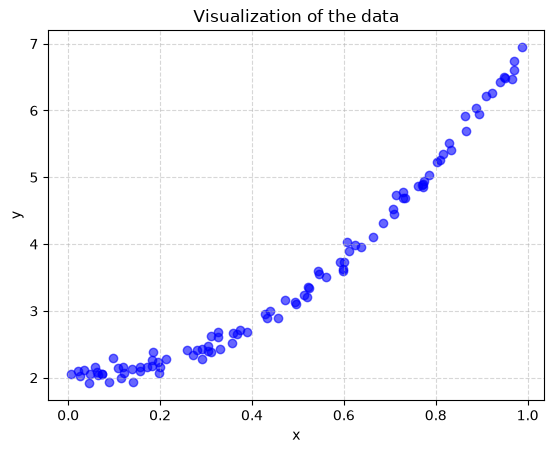

In [2]:
import matplotlib.pyplot as plt

plt.scatter(x, y, color='blue', alpha=0.6)

plt.title('Visualization of the data')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Task 1

Write your own code (following the examples under the regression notes) for computing the parametrization of the data set fitting a second-order polynomial.

#### Solution:

First we must define $\mathbf{X} \in \mathbb{R}^{n \times p}$ as the second-order polynomial matrix where $n$ is the number of observations and $p$ is the number of features in the design matrix. In order to achieve a second-order polynomial, we set $p=3$, while the 100 data points we generated earlier gives us $n=100$.

In [3]:
degree = 2

X = np.column_stack([x**i for i in range(degree + 1)])

We can now use the definition of $\mathbf{X}$ and the given $y$ to compute the ordinary least squares using the function provided in Hjorth-Jensen (2026, p. 83) as below.

In [4]:
def ols(X, y):
    """Ordinary least squares through singular value decomposition.""" 
    U, s, Vt = np.linalg.svd(X, full_matrices=False) 
    return Vt.T @ (U.T @ y / s)

theta = ols(X, y)
theta

array([ 2.05614027, -0.27222412,  5.23242548])

This gives us the solution
$$
\hat{\theta} =
\begin{bmatrix}
2.05614027 \\
-0.27222412 \\
5.23242548
\end{bmatrix},
$$
which is close to the true function $f(x) = 2 + 5x^2$ (plus some noise).

We can plot this over the data to see the fit.

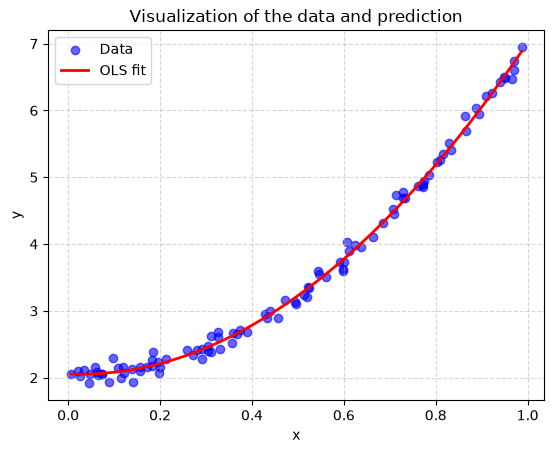

In [5]:
plt.scatter(x, y, color='blue', alpha=0.6, label='Data')

def f(x):
    return theta[0] + x*theta[1] + x**2 * theta[2]

x_grid = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_grid = f(x_grid)
plt.plot(x_grid, y_grid, color='red', linewidth=2, label='OLS fit')

plt.title('Visualization of the data and prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Task 2

Use thereafter scikit-learn (see again the examples in the regression slides) and compare with your own code.

#### Solution:

scikit-learn provides ordinary least squares through its `LinearRegression` class. 


In [6]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression(fit_intercept=False).fit(X, y)
print(reg.coef_)

[ 2.05614027 -0.27222412  5.23242548]


We see that we get exactly the same solution here as we did with the `ols` function we took from Hjorth-Jensen (2026) earlier.

### Task 3

Using scikit-learn, compute also the mean square error, a risk metric corresponding to the expected value of the squared (quadratic) error defined as
$$
MSE(\boldsymbol{y},\boldsymbol{\tilde{y}}) = \frac{1}{n} \sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2
$$
and the $R^2$ score function.

If $\tilde{\boldsymbol{y}}_i$ is the predicted value of the $i$-th sample and $y_i$ is the corresponding true value, then the score $R^2$ is defined as
$$
R^2(\boldsymbol{y}, \tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n - 1} (y_i - \tilde{y}_i)^2}{\sum_{i=0}^{n - 1} (y_i - \bar{y})^2},
$$
where we have defined the mean value  of $\boldsymbol{y}$ as
$$
\bar{y} =  \frac{1}{n} \sum_{i=0}^{n - 1} y_i.
$$

You can use the functionality included in scikit-learn. If you feel for it, you can use your own program and define functions which compute the above two functions. Discuss the meaning of these results. Try also to vary the coefficient in front of the added stochastic noise term and discuss the quality of the fits.

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

y_tilde = X @ theta

mse = mean_squared_error(y, y_tilde)
r2  = r2_score(y, y_tilde)

print(f"{mse = }, {r2 = }")

mse = 0.007771936663502363, r2 = 0.9964562915831219


We observe a MSE score of $~0.008$ and an $R^2$ of $~0.996$. This means that our regression model has fit the dataset cleanly, as we can see in the figure presented earlier.

## Exercise 3: Split data in test and training data

In this exercise we want you to to compute the MSE for the training data and the test data as function of the complexity of a polynomial, that is the degree of a given polynomial.

The aim is to reproduce Figure 2.11 of Hastie et al.

Our data is defined by $x \in [-3, 3]$ with a total of for example $n=100$ data points. You should try to vary the number of data points $n$ in your analysis.

In [8]:
np.random.seed()
n = 100
# Make data set.
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x-2)**2)+ np.random.normal(0, 0.1, x.shape)
y = y.ravel()

where $y$ is the function we want to fit with a given polynomial.

a) Write a first code which sets up a design matrix $X$ defined by a fifth-order polynomial and split your data set in training and test data.



In [9]:
from sklearn.model_selection import train_test_split

# Create design matrix X of degree 5
degree = 5
X = np.column_stack([x**i for i in range(degree + 1)])

# Split dataset into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

b) Write thereafter (using either scikit-learn or your matrix inversion code using for example numpy) and perform an ordinary least squares fitting and compute the mean squared error for the training data and the test data. These calculations should apply to a model given by a fifth-order polynomial.

Using the functions provided in Hjorth-Jensen (2026, p. 84), we can write the functions for mean-square error.

In [10]:
# Fit regression model
theta = ols(X_train, y_train)

def mse(y, y_tilde):
    return np.mean((y-y_tilde)**2)

y_train_tilde = X_train @ theta
y_test_tilde  = X_test @ theta

mse_train = mse(y_train, y_train_tilde)
mse_test  = mse(y_test, y_test_tilde)

print(f"Training MSE: {mse_train:.2f}")
print(f"Test MSE:     {mse_test:.2f}")

Training MSE: 0.02
Test MSE:     0.02


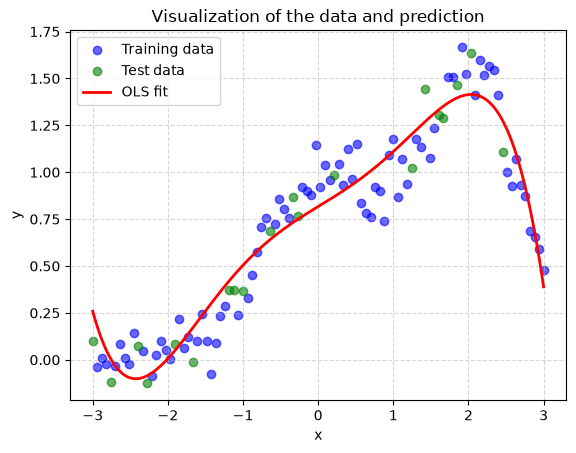

In [11]:
plt.scatter(X_train[:, 1], y_train, color='blue', alpha=0.6, label='Training data')
plt.scatter(X_test[:, 1], y_test, color='green', alpha=0.6, label='Test data')

x_grid = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
X_grid = np.column_stack([x_grid**i for i in range(degree + 1)])
y_grid = X_grid @ theta
plt.plot(x_grid, y_grid, color='red', linewidth=2, label='OLS fit')

plt.title('Visualization of the data and prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

c) Add now a model which allows you to make polynomials up to degree $15$. Perform a standard OLS fitting of the training data and compute the MSE for the training and test data and plot both test and training data MSE as functions of the polynomial degree. Compare what you see with Figure 2.11 of Hastie et al. Comment your results. For which polynomial degree do you find an optimal MSE (smallest value)?

In [12]:
# Create design matrix X of degree 15
degree = 15
X_15 = np.column_stack([x**i for i in range(degree + 1)])

# Split dataset into training and test data
X_train_15, X_test_15, y_train_15, y_test_15 = train_test_split(X_15, y, test_size=0.2, random_state=42)

# Fit regression model
theta_15 = ols(X_train_15, y_train_15)

def mse(y, y_tilde):
    return np.mean((y-y_tilde)**2)

y_train_tilde_15 = X_train_15 @ theta_15
y_test_tilde_15  = X_test_15 @ theta_15

mse_train_15 = mse(y_train_15, y_train_tilde_15)
mse_test_15  = mse(y_test_15, y_test_tilde_15)

print(f"Training MSE: {mse_train_15:.2f}")
print(f"Test MSE:     {mse_test_15:.2f}")

Training MSE: 0.01
Test MSE:     0.01


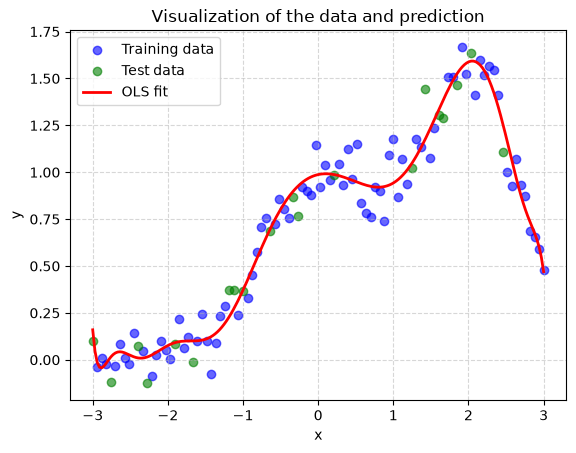

In [13]:
plt.scatter(X_train_15[:, 1], y_train_15, color='blue', alpha=0.6, label='Training data')
plt.scatter(X_test_15[:, 1], y_test_15, color='green', alpha=0.6, label='Test data')

x_grid = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
X_grid = np.column_stack([x_grid**i for i in range(degree + 1)])
y_grid = X_grid @ theta_15
plt.plot(x_grid, y_grid, color='red', linewidth=2, label='OLS fit')

plt.title('Visualization of the data and prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()